# 🍕 CalorieSnap — MobileNetV3Small Food Classifier

```
Food-101 → MobileNetV3Small 파인튜닝 (keras.applications)
         → TFLite INT8 변환 → Flutter 온디바이스 배포
```

| 항목 | 값 |
|------|----|
| 모델 | MobileNetV3Small (keras.applications) |
| 입력 | 224×224×3, float32, **[-1, 1]** 정규화 |
| 출력 | 20개 클래스 softmax |
| 변환 | TFLite INT8 양자화 (~3MB) |

⚠️ **런타임 → 런타임 유형 변경 → T4 GPU 선택**

## 1️⃣ 환경 설치

In [ ]:
# keras_hub 불필요 — keras.applications 사용
!pip install -q tensorflow-datasets>=4.9 matplotlib seaborn scikit-learn
print('✅ 설치 완료')

✅ 설치 완료


In [ ]:
import os, json, shutil, time
import numpy as np
import tensorflow as tf
import keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2️⃣ Google Drive 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/CalorieSnap'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'저장 경로: {SAVE_DIR}')

Mounted at /content/drive
저장 경로: /content/drive/MyDrive/CalorieSnap


## 3️⃣ 설정

In [ ]:
SELECTED_CLASSES = [
    'pizza',
    'hamburger',
    'fried_rice',
    'ramen',
    'sushi',
    'steak',
    'donuts',
    'ice_cream',
    'chicken_wings',
    'spaghetti_bolognese',
    'spaghetti_carbonara',
    'cup_cakes',
    'french_toast',
    'risotto',
    'macaroni_and_cheese',
    'grilled_salmon',
    'bibimbap',
    'miso_soup',
    'tacos',
    'chocolate_cake',
]

NUM_CLASSES   = len(SELECTED_CLASSES)  # 20
IMG_SIZE      = 224
BATCH_SIZE    = 32
SEED          = 42

STAGE1_EPOCHS = 5     # 헤드만 학습 (base_model 동결)
STAGE2_EPOCHS = 20    # 전체 파인튜닝
STAGE1_LR     = 1e-3
STAGE2_LR     = 1e-4

print(f'클래스 수: {NUM_CLASSES}')
for i, c in enumerate(SELECTED_CLASSES):
    print(f'  {i:2d}. {c}')

클래스 수: 20
   0. pizza
   1. hamburger
   2. fried_rice
   3. ramen
   4. sushi
   5. steak
   6. donuts
   7. ice_cream
   8. chicken_wings
   9. spaghetti_bolognese
  10. spaghetti_carbonara
  11. cup_cakes
  12. french_toast
  13. risotto
  14. macaroni_and_cheese
  15. grilled_salmon
  16. bibimbap
  17. miso_soup
  18. tacos
  19. chocolate_cake


## 4️⃣ Food-101 로드 & 필터링

In [ ]:
print('Food-101 로드 중 (최초 실행 시 ~20분)...')
(ds_train_full, ds_val_full, ds_test_full), info = tfds.load(
    'food101',
    split=['train[:80%]', 'train[80%:]', 'validation'],
    with_info=True,
    as_supervised=True,
)

all_class_names = info.features['label'].names
print(f'Food-101 전체 클래스: {len(all_class_names)}')

# 선택 클래스 인덱스 확인
class_to_original_idx = {}
missing = []
for cls in SELECTED_CLASSES:
    if cls in all_class_names:
        class_to_original_idx[cls] = all_class_names.index(cls)
    else:
        missing.append(cls)

if missing:
    print(f'⚠️  없는 클래스: {missing}')
else:
    print('✅ 20개 클래스 모두 확인됨')

original_idx_to_new = {
    original_idx: new_idx
    for new_idx, (cls, original_idx) in enumerate(class_to_original_idx.items())
}
valid_original_indices = list(class_to_original_idx.values())

print('\n인덱스 매핑:')
for new_idx, cls in enumerate(SELECTED_CLASSES):
    print(f'  {new_idx:2d}. {cls:<25} (food101 idx: {class_to_original_idx[cls]})')

Food-101 로드 중 (최초 실행 시 ~20분)...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.AJLUWI_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.AJLUWI_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.
Food-101 전체 클래스: 101
✅ 20개 클래스 모두 확인됨

인덱스 매핑:
   0. pizza                     (food101 idx: 76)
   1. hamburger                 (food101 idx: 53)
   2. fried_rice                (food101 idx: 44)
   3. ramen                     (food101 idx: 81)
   4. sushi                     (food101 idx: 95)
   5. steak                     (food101 idx: 93)
   6. donuts                    (food101 idx: 31)
   7. ice_cream                 (food101 idx: 58)
   8. chicken_wings             (food101 idx: 20)
   9. spaghetti_bolognese       (food101 idx: 90)
  10. spaghetti_carbonara       (food101 idx: 91)
  11. cup_cakes                 (food101 idx: 29)
  12. french_toast              (food101 idx: 42)
  13. risotto                   (food101 idx: 84)
  14. macaroni_and_cheese       (food101 idx: 62)
  15. grilled_salmon            (food101 idx: 50)
  16. bibimbap                

In [ ]:
def filter_fn(image, label):
    label_int = tf.cast(label, tf.int32)
    return tf.reduce_any(tf.equal(label_int, valid_original_indices))

def remap_fn(image, label):
    original_indices = tf.constant(list(original_idx_to_new.keys()), dtype=tf.int32)
    new_indices      = tf.constant(list(original_idx_to_new.values()), dtype=tf.int32)
    label_int        = tf.cast(label, tf.int32)
    matches          = tf.equal(original_indices, label_int)
    new_label        = tf.reduce_sum(
        tf.where(matches, new_indices, tf.zeros_like(new_indices))
    )
    return image, tf.cast(new_label, tf.int32)

ds_train_filtered = ds_train_full.filter(filter_fn).map(remap_fn)
ds_val_filtered   = ds_val_full.filter(filter_fn).map(remap_fn)
ds_test_filtered  = ds_test_full.filter(filter_fn).map(remap_fn)

print('샘플 수 카운트 중...')
n_train = sum(1 for _ in ds_train_filtered)
n_val   = sum(1 for _ in ds_val_filtered)
n_test  = sum(1 for _ in ds_test_filtered)
print(f'Train: {n_train:,}  |  Val: {n_val:,}  |  Test: {n_test:,}')

샘플 수 카운트 중...
Train: 12,029  |  Val: 2,971  |  Test: 5,000


## 5️⃣ 전처리 파이프라인

**CenterCrop + [-1, 1] 정규화**

MobileNetV3Small 사전학습 가중치는 `[-1, 1]` 입력을 기대합니다 (`pixel / 127.5 - 1.0`).
Flutter `food_analysis_service.dart` 와 반드시 동일하게 적용해야 합니다.

steps_per_epoch  : 375
validation_steps : 92


/tmp/ipykernel_1234/2616761285.py:69: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1234/2616761285.py:69: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1234/2616761285.py:69: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1234/2616761285.py:69: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1234/2616761285.py:69: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1234/2616761285.py:69: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1234/2616761285.py:70: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.s

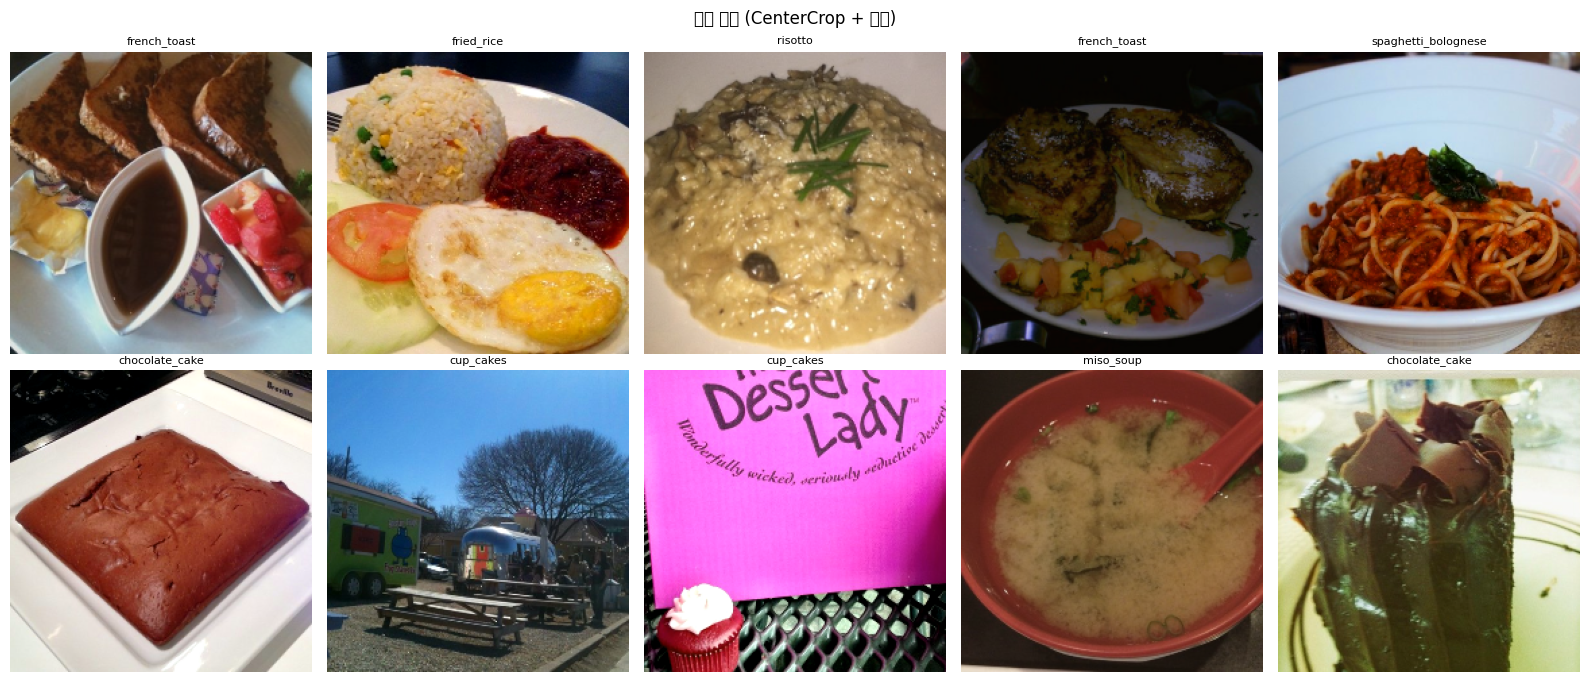

✅ 전처리 확인 완료


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE


def center_crop(image):
    """비율 유지 정사각형 크롭 — Flutter copyCrop() 과 동일 로직"""
    h         = tf.shape(image)[0]
    w         = tf.shape(image)[1]
    crop_size = tf.minimum(h, w)
    offset_h  = (h - crop_size) // 2
    offset_w  = (w - crop_size) // 2
    return tf.image.crop_to_bounding_box(
        image, offset_h, offset_w, crop_size, crop_size
    )


def preprocess_train(image, label):
    # ── 1. CenterCrop ──────────────────────────────────────────
    image = center_crop(image)
    # ── 2. 랜덤 증강 ──────────────────────────────────────────
    image = tf.image.resize(image, [IMG_SIZE + 20, IMG_SIZE + 20])
    image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, 3])
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0, 255)
    # ── 3. [-1, 1] 정규화 (MobileNetV3Small 기준) ──────────────
    image = tf.cast(image, tf.float32) / 127.5 - 1.0
    return image, label


def preprocess_eval(image, label):
    # ── 1. CenterCrop ──────────────────────────────────────────
    image = center_crop(image)
    # ── 2. 리사이즈 & [-1, 1] 정규화 ──────────────────────────
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 127.5 - 1.0
    return image, label


def build_dataset(ds, preprocess_fn, shuffle=False, repeat=False):
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=SEED)
    ds = ds.map(preprocess_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if repeat:
        ds = ds.repeat()
    return ds.prefetch(AUTOTUNE)


train_ds = build_dataset(ds_train_filtered, preprocess_train, shuffle=True, repeat=True)
val_ds   = build_dataset(ds_val_filtered,   preprocess_eval)
test_ds  = build_dataset(ds_test_filtered,  preprocess_eval)

steps_per_epoch  = n_train // BATCH_SIZE
validation_steps = n_val   // BATCH_SIZE
print(f'steps_per_epoch  : {steps_per_epoch}')
print(f'validation_steps : {validation_steps}')

# 샘플 시각화 (역정규화: [-1,1] → [0,1])
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for images, labels in train_ds.take(1):
    for i, ax in enumerate(axes.flat):
        img_show = (images[i].numpy() + 1.0) / 2.0  # [-1,1] → [0,1]
        ax.imshow(np.clip(img_show, 0, 1))
        ax.set_title(SELECTED_CLASSES[labels[i].numpy()], fontsize=8)
        ax.axis('off')
plt.suptitle('학습 샘플 (CenterCrop + 증강)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/sample_augmented.png', dpi=100)
plt.show()
print('✅ 전처리 확인 완료')

## 6️⃣ 모델 구성 (MobileNetV3Small)

In [ ]:
# ─────────────────────────────────────────────────────────────
#  keras.applications.MobileNetV3Small
#  - 파라미터: ~2.5M
#  - include_preprocessing=False: 섹션5에서 직접 [-1,1] 정규화
#  - include_top=False: GlobalAveragePooling + Dropout + Dense 직접 추가
# ─────────────────────────────────────────────────────────────
def build_model(num_classes, freeze_backbone=True):
    base_model = keras.applications.MobileNetV3Small(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet',
        include_preprocessing=False,
    )
    base_model.trainable = not freeze_backbone

    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
    x       = base_model(inputs, training=not freeze_backbone)
    x       = keras.layers.GlobalAveragePooling2D(name='gap')(x)
    x       = keras.layers.Dropout(0.3, name='dropout')(x)
    outputs = keras.layers.Dense(
        num_classes, activation='softmax', name='predictions'
    )(x)

    return keras.Model(inputs, outputs, name='mobilenetv3_small_food'), base_model


model, base_model = build_model(NUM_CLASSES, freeze_backbone=True)
model.summary()

trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
frozen    = sum(np.prod(w.shape) for w in model.non_trainable_weights)
print(f'\n학습 가능: {trainable:,}  |  동결: {frozen:,}')

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv3_small_food"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 20)             │        11,540 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 950,660 (3.63 MB)

 Trainable params: 11,540 (45.08 KB)

 Non-trainable params: 939,120 (3.58 MB)


학습 가능: 11,540  |  동결: 939,120


## 7️⃣ Stage 1 — 헤드 학습 (base_model 동결)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('=== Stage 1: 헤드 학습 시작 ===')
t0 = time.time()
history1 = model.fit(
    train_ds,
    epochs=STAGE1_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3,
            restore_best_weights=True, verbose=1
        ),
    ],
    verbose=1,
)
print(f'완료 ({time.time()-t0:.0f}초)  |  최고 val_accuracy: {max(history1.history["val_accuracy"]):.4f}')

=== Stage 1: 헤드 학습 시작 ===
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 143s 307ms/step - accuracy: 0.4713 - loss: 1.7431 - val_accuracy: 0.7069 - val_loss: 1.0214
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 120s 300ms/step - accuracy: 0.6743 - loss: 1.0735 - val_accuracy: 0.7507 - val_loss: 0.8630
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 114s 306ms/step - accuracy: 0.7095 - loss: 0.9458 - val_accuracy: 0.7694 - val_loss: 0.8050
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 114s 305ms/step - accuracy: 0.7294 - loss: 0.8839 - val_accuracy: 0.7738 - val_loss: 0.7635
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 117s 314ms/step - accuracy: 0.7394 - loss: 0.8457 - val_accuracy: 0.7796 - val_loss: 0.7564
Restoring model weights from the end of the best epoch: 5.
완료 (627초)  |  최고 val_accuracy: 0.7796


## 8️⃣ Stage 2 — 파인튜닝 (base_model 상위 50% 해제)

In [ ]:
# base_model 상위 50% 레이어 학습 가능으로 변경
base_model.trainable = True
freeze_until = len(base_model.layers) // 2
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

trainable_now = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f'파인튜닝 파라미터: {trainable_now:,}  ({freeze_until}/{len(base_model.layers)} 레이어 동결)')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('\n=== Stage 2: 파인튜닝 시작 ===')
t0 = time.time()
history2 = model.fit(
    train_ds,
    epochs=STAGE2_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=5,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-6, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath='/content/best_model.keras',
            monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
    ],
    verbose=1,
)
print(f'완료 ({time.time()-t0:.0f}초)  |  최고 val_accuracy: {max(history2.history["val_accuracy"]):.4f}')

파인튜닝 파라미터: 799,796  (78/156 레이어 동결)

=== Stage 2: 파인튜닝 시작 ===
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.6415 - loss: 1.2155
Epoch 1: val_accuracy improved from None to 0.63247, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 165s 322ms/step - accuracy: 0.6977 - loss: 1.0148 - val_accuracy: 0.6325 - val_loss: 1.2798 - learning_rate: 1.0000e-04
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.7605 - loss: 0.7668
Epoch 2: val_accuracy improved from 0.63247 to 0.71026, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 132s 308ms/step - accuracy: 0.7656 - loss: 0.7470 - val_accuracy: 0.7103 - val_loss: 0.9519 - learning_rate: 1.0000e-04
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.7951 - loss: 0.6591
Epoch 3: val_accuracy improved from 0.71026 to 0.77717, savin

/tmp/ipykernel_1234/2779077493.py:19: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1234/2779077493.py:19: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1234/2779077493.py:19: UserWarning: Glyph 53916 (\N{HANGUL SYLLABLE TYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1234/2779077493.py:19: UserWarning: Glyph 45789 (\N{HANGUL SYLLABLE NING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1234/2779077493.py:19: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1234/2779077493.py:19: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1234/2779077493.py:19: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_lay

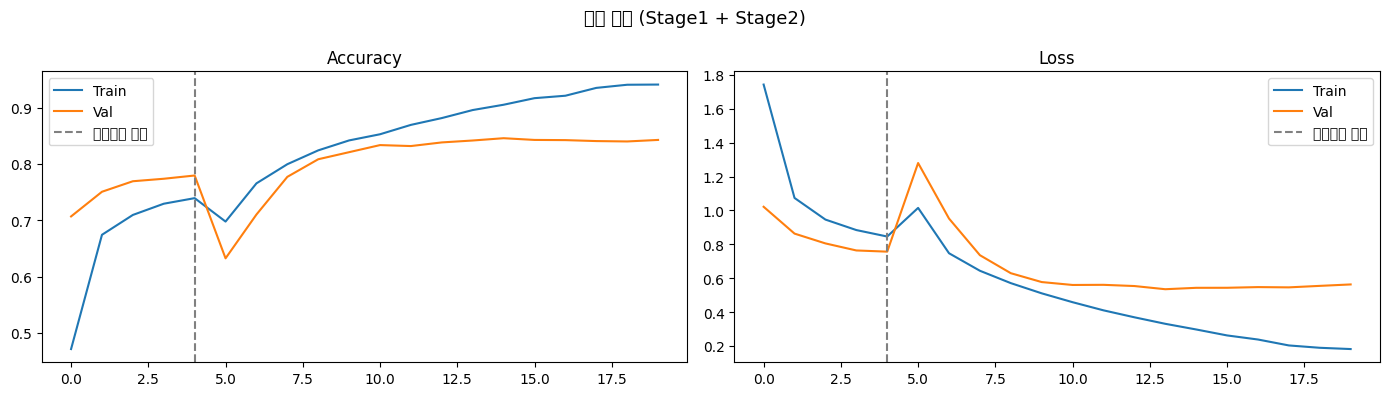

In [ ]:
# 학습 곡선
acc   = history1.history['accuracy']     + history2.history['accuracy']
val   = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss  = history1.history['loss']         + history2.history['loss']
vloss = history1.history['val_loss']     + history2.history['val_loss']
split = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, t, v, title in [
    (axes[0], acc,  val,   'Accuracy'),
    (axes[1], loss, vloss, 'Loss'),
]:
    ax.plot(t, label='Train')
    ax.plot(v, label='Val')
    ax.axvline(x=split - 1, color='gray', linestyle='--', label='파인튜닝 시작')
    ax.set_title(title)
    ax.legend()
plt.suptitle('학습 곡선 (Stage1 + Stage2)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120)
plt.show()

## 9️⃣ 평가 (Test Set)

In [ ]:
best_model = keras.models.load_model('/content/best_model.keras')

test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f'\n✅ Test Accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)')
print(f'   Test Loss     : {test_loss:.4f}')

157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 245ms/step - accuracy: 0.8824 - loss: 0.3848

✅ Test Accuracy : 0.8824  (88.2%)
   Test Loss     : 0.3848


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


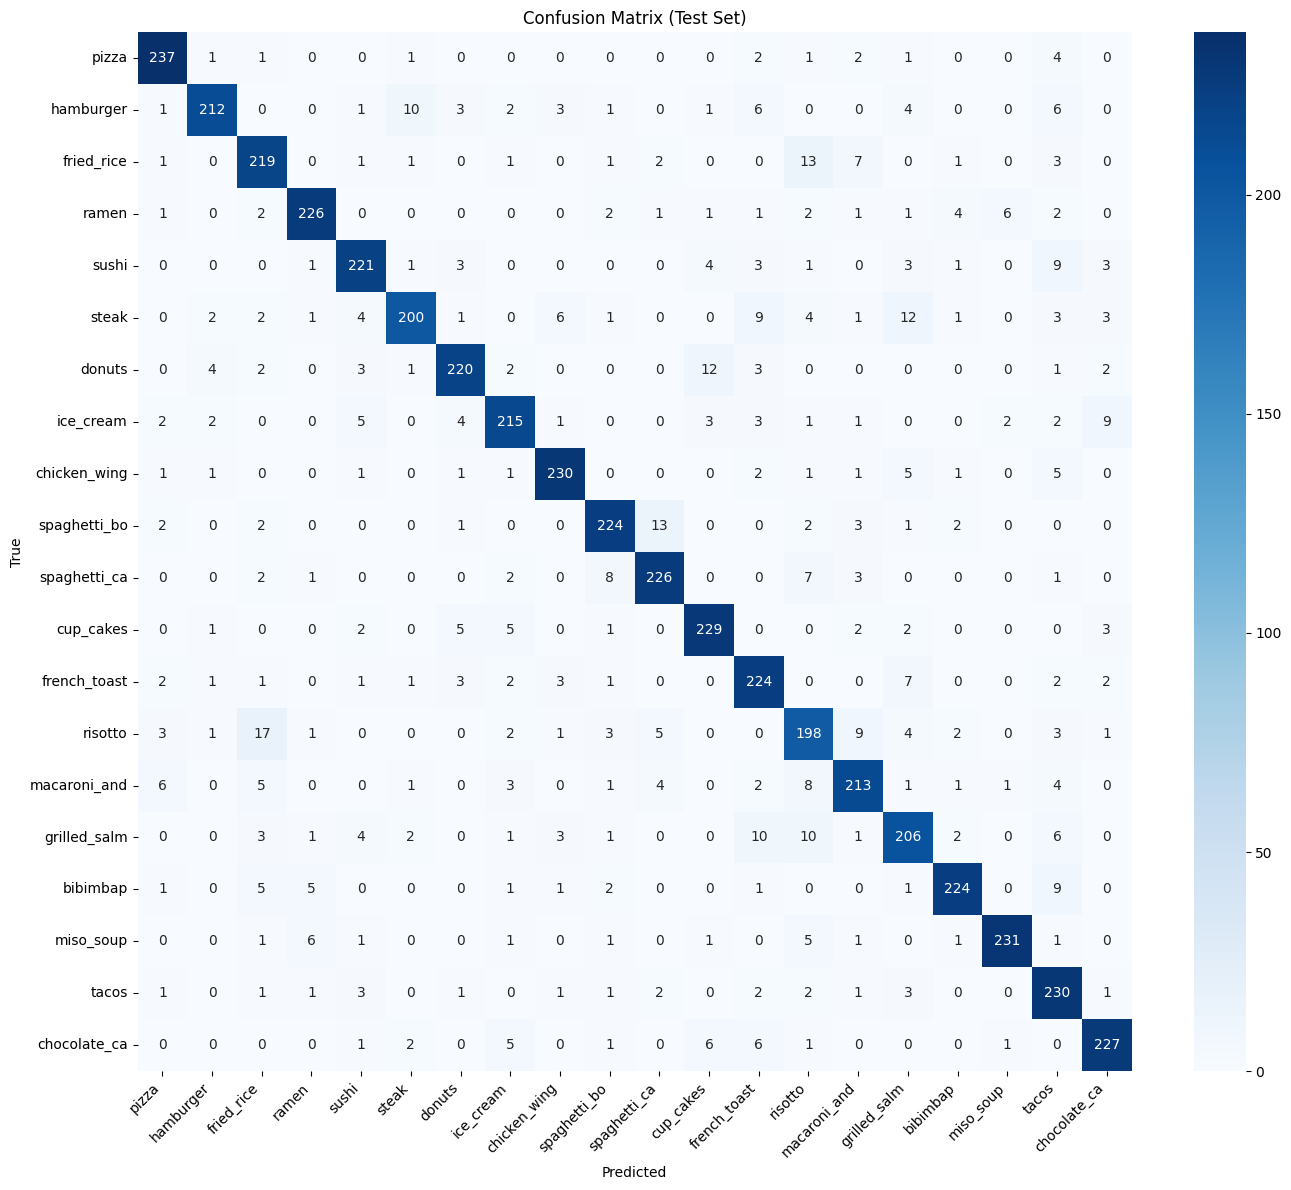

                     precision    recall  f1-score   support

              pizza       0.92      0.95      0.93       250
          hamburger       0.94      0.85      0.89       250
         fried_rice       0.83      0.88      0.85       250
              ramen       0.93      0.90      0.92       250
              sushi       0.89      0.88      0.89       250
              steak       0.91      0.80      0.85       250
             donuts       0.91      0.88      0.89       250
          ice_cream       0.88      0.86      0.87       250
      chicken_wings       0.92      0.92      0.92       250
spaghetti_bolognese       0.90      0.90      0.90       250
spaghetti_carbonara       0.89      0.90      0.90       250
          cup_cakes       0.89      0.92      0.90       250
       french_toast       0.82      0.90      0.85       250
            risotto       0.77      0.79      0.78       250
macaroni_and_cheese       0.87      0.85      0.86       250
     grilled_salmon    

In [ ]:
# Confusion Matrix
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm          = confusion_matrix(y_true, y_pred)
short_names = [c[:12] for c in SELECTED_CLASSES]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=short_names, yticklabels=short_names
)
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=120)
plt.show()

print(classification_report(y_true, y_pred, target_names=SELECTED_CLASSES))

## 🔟 TFLite 변환 (INT8 양자화)

In [ ]:
# Representative dataset — INT8 보정용 (200장)
def representative_dataset():
    count = 0
    for images, _ in val_ds:
        for img in images:
            yield [tf.expand_dims(img, 0)]
            count += 1
            if count >= 200:
                return

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations             = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset   = representative_dataset
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.TFLITE_BUILTINS,
]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

print('TFLite 변환 중... (1~3분)')
tflite_model = converter.convert()

MODEL_PATH = '/content/mobilenetv3_food.tflite'
with open(MODEL_PATH, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(MODEL_PATH) / 1024 / 1024
print(f'\n✅ TFLite 저장 완료: {size_mb:.2f} MB')

TFLite 변환 중... (1~3분)
Saved artifact at '/tmp/tmpd6gmqdcb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  136976013502672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136977349318736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976013499600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976013501520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976013503824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976013504208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976013504400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976013503440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976013504016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976013504976: TensorSpec(shape=(), dtype=tf.resource, name=

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



✅ TFLite 저장 완료: 1.17 MB


In [ ]:
# TFLite 정확도 검증
interp = tf.lite.Interpreter(model_path=MODEL_PATH)
interp.allocate_tensors()

inp = interp.get_input_details()
out = interp.get_output_details()
print(f'입력 shape : {inp[0]["shape"]}  dtype: {inp[0]["dtype"]}')
print(f'출력 shape : {out[0]["shape"]}  dtype: {out[0]["dtype"]}')

correct, total = 0, 0
for images, labels in test_ds.unbatch().batch(1).take(300):
    interp.set_tensor(inp[0]['index'], images.numpy())
    interp.invoke()
    pred     = np.argmax(interp.get_tensor(out[0]['index']))
    correct += int(pred == labels.numpy()[0])
    total   += 1

tflite_acc = correct / total
print(f'\n✅ TFLite 정확도 ({total} 샘플): {tflite_acc:.4f}  ({tflite_acc*100:.1f}%)')

입력 shape : [  1 224 224   3]  dtype: <class 'numpy.float32'>
출력 shape : [ 1 20]  dtype: <class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



✅ TFLite 정확도 (300 샘플): 0.5833  (58.3%)


## 1️⃣1️⃣ labels.json 생성

In [ ]:
LABELS_DATA = [
    {'index': 0,  'label': 'pizza',               'name_ko': '피자'},
    {'index': 1,  'label': 'hamburger',            'name_ko': '햄버거'},
    {'index': 2,  'label': 'fried_rice',           'name_ko': '볶음밥'},
    {'index': 3,  'label': 'ramen',                'name_ko': '라면'},
    {'index': 4,  'label': 'sushi',                'name_ko': '스시'},
    {'index': 5,  'label': 'steak',                'name_ko': '스테이크'},
    {'index': 6,  'label': 'donuts',               'name_ko': '도넛'},
    {'index': 7,  'label': 'ice_cream',            'name_ko': '아이스크림'},
    {'index': 8,  'label': 'chicken_wings',        'name_ko': '치킨 윙'},
    {'index': 9,  'label': 'spaghetti_bolognese',  'name_ko': '스파게티 볼로네제'},
    {'index': 10, 'label': 'spaghetti_carbonara',  'name_ko': '스파게티 카르보나라'},
    {'index': 11, 'label': 'cup_cakes',            'name_ko': '컵케이크'},
    {'index': 12, 'label': 'french_toast',         'name_ko': '프렌치 토스트'},
    {'index': 13, 'label': 'risotto',              'name_ko': '리조또'},
    {'index': 14, 'label': 'macaroni_and_cheese',  'name_ko': '맥앤치즈'},
    {'index': 15, 'label': 'grilled_salmon',       'name_ko': '연어 구이'},
    {'index': 16, 'label': 'bibimbap',             'name_ko': '비빔밥'},
    {'index': 17, 'label': 'miso_soup',            'name_ko': '미소국'},
    {'index': 18, 'label': 'tacos',                'name_ko': '타코'},
    {'index': 19, 'label': 'chocolate_cake',       'name_ko': '초코 케이크'},
]

assert [d['label'] for d in LABELS_DATA] == SELECTED_CLASSES, '❌ 순서 불일치!'

LABELS_PATH = '/content/labels.json'
with open(LABELS_PATH, 'w', encoding='utf-8') as f:
    json.dump(LABELS_DATA, f, ensure_ascii=False, indent=2)

print('✅ labels.json 생성 완료')
print(json.dumps(LABELS_DATA, ensure_ascii=False, indent=2))

✅ labels.json 생성 완료
[
  {
    "index": 0,
    "label": "pizza",
    "name_ko": "피자"
  },
  {
    "index": 1,
    "label": "hamburger",
    "name_ko": "햄버거"
  },
  {
    "index": 2,
    "label": "fried_rice",
    "name_ko": "볶음밥"
  },
  {
    "index": 3,
    "label": "ramen",
    "name_ko": "라면"
  },
  {
    "index": 4,
    "label": "sushi",
    "name_ko": "스시"
  },
  {
    "index": 5,
    "label": "steak",
    "name_ko": "스테이크"
  },
  {
    "index": 6,
    "label": "donuts",
    "name_ko": "도넛"
  },
  {
    "index": 7,
    "label": "ice_cream",
    "name_ko": "아이스크림"
  },
  {
    "index": 8,
    "label": "chicken_wings",
    "name_ko": "치킨 윙"
  },
  {
    "index": 9,
    "label": "spaghetti_bolognese",
    "name_ko": "스파게티 볼로네제"
  },
  {
    "index": 10,
    "label": "spaghetti_carbonara",
    "name_ko": "스파게티 카르보나라"
  },
  {
    "index": 11,
    "label": "cup_cakes",
    "name_ko": "컵케이크"
  },
  {
    "index": 12,
    "label": "french_toast",
    "name_ko": "프렌치 토스트"
  },
  {
    "ind

## 1️⃣2️⃣ Drive 저장 & 다운로드

In [ ]:
files_to_save = {
    MODEL_PATH:                      'mobilenetv3_food.tflite',
    LABELS_PATH:                     'labels.json',
    '/content/best_model.keras':     'best_model.keras',
    '/content/training_curves.png':  'training_curves.png',
    '/content/confusion_matrix.png': 'confusion_matrix.png',
    '/content/sample_augmented.png': 'sample_augmented.png',
}

print(f'=== Drive 저장: {SAVE_DIR} ===')
for src, name in files_to_save.items():
    if os.path.exists(src):
        dst = os.path.join(SAVE_DIR, name)
        shutil.copy(src, dst)
        print(f'  ✅ {name:<40} ({os.path.getsize(dst)/1024:.1f} KB)')
    else:
        print(f'  ⚠️  {name} — 없음')

print('\n=== Flutter 배포 파일 ===')
print('  mobilenetv3_food.tflite  →  assets/models/')
print('  labels.json              →  assets/models/')

=== Drive 저장: /content/drive/MyDrive/CalorieSnap ===
  ✅ mobilenetv3_food.tflite                  (1197.8 KB)
  ✅ labels.json                              (1.6 KB)
  ✅ best_model.keras                         (10564.8 KB)
  ✅ training_curves.png                      (66.4 KB)
  ✅ confusion_matrix.png                     (170.3 KB)
  ✅ sample_augmented.png                     (1448.4 KB)

=== Flutter 배포 파일 ===
  mobilenetv3_food.tflite  →  assets/models/
  labels.json              →  assets/models/


In [ ]:
from google.colab import files
files.download(MODEL_PATH)
files.download(LABELS_PATH)
print('✅ 다운로드 완료')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 다운로드 완료
